In [2]:
!pip install bs4

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import bs4 
import itertools
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_csv("steam_all_data.csv", low_memory=False)
#print(df.head())

In [3]:
import datetime
df2 = df.copy()
#Date Cleaning
df2['release_date'] = pd.to_datetime(df2['release_date'], errors='coerce')
df2['release_year']= df2['release_date'].dt.year
#print(df2['release_year'])
df2['release_year']


0        2000
1        2003
2        1999
3        1998
4        2004
         ... 
26863    2019
26864    2019
26865    2019
26866    2019
26867    2019
Name: release_year, Length: 26868, dtype: int32

In [4]:
print(df2['windows_sup'].head(10))


KeyError: 'windows_sup'

In [4]:
#Platforms:
df2['platforms'].dtype
df2['platforms_2'] = df2['platforms'].str.split(';')
df2['windows_sup'] = df2['platforms_2'].apply(lambda x: 1 if 'windows' in x else 0)
df2['mac_sup'] = df2['platforms_2'].apply(lambda x: 1 if 'mac' in x else 0)
df2['linux_sup'] = df2['platforms_2'].apply(lambda x: 1 if 'linux' in x else 0)
df2

,steam_appid,pc_requirements,mac_requirements,linux_requirements,minimum,recommended,steam_appid (Right),website,support_url,support_email,...,steam_appid (Right) (Right) (Right),header_image,screenshots,background,movies,release_year,platforms_2,windows_sup,mac_sup,linux_sup
0,10,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,10,NaN,http://steamcommunity.com/app/10,NaN,...,10,https://steamcdn-a.akamaihd.net/steam/apps/10/...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/10/...,NaN,2000,"[windows, mac, linux]",1,1,1
1,30,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,30,http://www.dayofdefeat.com/,NaN,NaN,...,30,https://steamcdn-a.akamaihd.net/steam/apps/30/...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/30/...,NaN,2003,"[windows, mac, linux]",1,1,1
2,50,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,50,NaN,https://help.steampowered.com,NaN,...,50,https://steamcdn-a.akamaihd.net/steam/apps/50/...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/50/...,NaN,1999,"[windows, mac, linux]",1,1,1
3,70,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,70,http://www.half-life.com/,http://steamcommunity.com/app/70,NaN,...,70,https://steamcdn-a.akamaihd.net/steam/apps/70/...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/70/...,NaN,1998,"[windows, mac, linux]",1,1,1
4,80,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,[],[],"500 mhz processor, 96mb ram, 16mb video card, ...",NaN,80,NaN,http://steamcommunity.com/app/80,NaN,...,80,https://steamcdn-a.akamaihd.net/steam/apps/80/...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/80/...,NaN,2004,"[windows, mac, linux]",1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26863,1065230,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],[],OS: Windows 7 Processor: Inter Core i7 Memory:...,NaN,1065230,NaN,https://goldlogsh.wixsite.com/myapps,zhang_frank@hotmail.com,...,1065230,https://steamcdn-a.akamaihd.net/steam/apps/106...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/106...,"[{'id': 256747452, 'name': 'Video', 'thumbnail...",2019,[windows],1,0,0
26864,1065570,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],[],"OS: Windows XP, Vista, 7, 8, 10 Processor: Int...",NaN,1065570,NaN,NaN,piziroggg@gmail.com,...,1065570,https://steamcdn-a.akamaihd.net/steam/apps/106...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/106...,"[{'id': 256747487, 'name': 'Game Trailer', 'th...",2019,[windows],1,0,0
26865,1065650,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],[],"OS: Windows 7, Windows 8, Windows 10 (32/64bit...",NaN,1065650,http://entwickler-x.de/super-star-blast,http://www.entwickler-x.de,mail@entwickler-x.de,...,1065650,https://steamcdn-a.akamaihd.net/steam/apps/106...,"[{'id': 0, 'path_thumbnail': 'https://steamcdn...",https://steamcdn-a.akamaihd.net/steam/apps/106...,"[{'id': 256747530, 'name': 'Gameplay Trailer',...",2019,[windows],1,0,0
26866,1066700,{'minimum': '<strong>Minimum:</strong><br><ul ...,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],OS: Windows XP or later Processor: 1.

In [7]:
import itertools

#Genres
#df2['genres'] = df2['genres'].str.split(';')
unique_gen = np.unique([*itertools.chain.from_iterable(df2['genres'])])
print(unique_gen)

for i in unique_gen:
    df2[i+"_genre"] = df2['genres'].apply(lambda x: 1 if i in x else 0)




['Accounting' 'Action' 'Adventure' 'Animation & Modeling'
 'Audio Production' 'Casual' 'Design & Illustration' 'Documentary'
 'Early Access' 'Education' 'Free to Play' 'Game Development' 'Gore'
 'Indie' 'Massively Multiplayer' 'Nudity' 'Photo Editing' 'RPG' 'Racing'
 'Sexual Content' 'Simulation' 'Software Training' 'Sports' 'Strategy'
 'Tutorial' 'Utilities' 'Video Production' 'Violent' 'Web Publishing']


In [10]:
#Categories:
df2['categories'] = df2['categories'].str.split(';')
unique_cat = np.unique([*itertools.chain.from_iterable(df2['categories'])])
print(unique_cat)

for i in unique_cat:
    df2[i+"_cat"] = df2['categories'].apply(lambda x: 1 if i in x else 0)

['Captions available' 'Co-op' 'Commentary available'
 'Cross-Platform Multiplayer' 'Full controller support' 'In-App Purchases'
 'Includes Source SDK' 'Includes level editor' 'Local Co-op'
 'Local Multi-Player' 'MMO' 'Mods' 'Mods (require HL2)' 'Multi-player'
 'Online Co-op' 'Online Multi-Player' 'Partial Controller Support'
 'Shared/Split Screen' 'Single-player' 'Stats' 'Steam Achievements'
 'Steam Cloud' 'Steam Leaderboards' 'Steam Trading Cards'
 'Steam Turn Notifications' 'Steam Workshop' 'SteamVR Collectibles'
 'VR Support' 'Valve Anti-Cheat enabled']


In [13]:
df2['Co-op_cat']

0        0
1        0
2        0
3        0
4        0
        ..
26863    0
26864    0
26865    1
26866    0
26867    0
Name: Co-op_cat, Length: 26868, dtype: int64

In [14]:
#check if game has some external support
support_cols = ['website','support_url', 'support_email']
df2['external_supp'] = df2[support_cols].notna().any(axis=1).astype(int)

In [15]:
#Minimum Requirements:
req_df = pd.read_csv("tech_spec.csv")

In [5]:
print(req_df['minimum'].count())
min = pd.DataFrame(req_df['pc_requirements'])
#min.to_csv('min_req.csv')
min
print(min.dtypes)

26864
pc_requirements    str
dtype: object


In [16]:
tech_df = pd.read_csv('tech_spec.csv')

In [17]:
import pandas as pd
import re
import ast
import numpy as np
from bs4 import BeautifulSoup

# --- 1. PRE-PROCESSING ---

def parse_pc_requirements(pc_req_str):
    if pd.isna(pc_req_str) or not isinstance(pc_req_str, str):
        return "NA"
    try:
        parsed = ast.literal_eval(pc_req_str)
    except (ValueError, SyntaxError):
        parsed = {"minimum": pc_req_str}
    
    section = parsed.get("minimum") or parsed.get("recommended", "")
    text = BeautifulSoup(section, "html.parser").get_text(" ")
    
    # Logic to remove "Recommended" text if it's accidentally baked into the Minimum string
    min_match = re.search(r"\bminimum\b", text, re.IGNORECASE)
    rec_match = re.search(r"(?:^|\s)recommended\s*:", text, re.IGNORECASE)
    if min_match and rec_match and rec_match.start() > min_match.start():
        text = text[: rec_match.start()]
    return text

# --- 2. THE REFINED EXTRACTORS ---

def extract_ram_mb(text):
    """Refined: Specifically looks for 'Memory' or 'RAM' labels to avoid GPU confusion."""
    # Pattern: Look for 'Memory' or 'RAM' followed by numbers
    match = re.search(r"(?:memory|ram)[\s:]*(\d+\.?\d*)\s*(gb|mb)", text, re.IGNORECASE)
    if not match:
        return None
    val = float(match.group(1))
    unit = match.group(2).lower()
    mb_val = int(val * 1024) if unit == "gb" else int(val)
    # Sanity Check: RAM is rarely less than 32MB or more than 128GB in this dataset
    return mb_val if 32 <= mb_val <= 131072 else None

def extract_gpu_mb(text):
    """Refined: Anchors to GPU keywords."""
    match = re.search(r"(?:graphics|video\s*card|vram|gpu|geforce|radeon)[^,\n]{0,60}?(\d+\.?\d*)\s*(gb|mb)", text, re.IGNORECASE)
    if not match:
        # Fallback: Check if number comes BEFORE the keyword (e.g., '512MB Video Card')
        match = re.search(r"(\d+\.?\d*)\s*(gb|mb)\s*(?:vram|video\s*card|graphics|gpu)", text, re.IGNORECASE)
    
    if not match: return None
    val = float(match.group(1))
    unit = match.group(2).lower()
    mb_val = int(val * 1024) if unit == "gb" else int(val)
    return mb_val if 8 <= mb_val <= 24576 else None

def extract_storage_mb(text):
    """Refined: Caps storage at 500GB to prevent data-entry errors like '2490 GB'."""
    match = re.search(r"(?:storage|hard\s*drive|disk\s*space|hdd|ssd)[^\n]{0,80}?(\d+\.?\d*)\s*(gb|mb)", text, re.IGNORECASE)
    if not match:
        match = re.search(r"(\d+\.?\d*)\s*(gb|mb)[^\n]{0,40}(?:available|free|required)?\s*(?:disk|storage|space|hdd|ssd)", text, re.IGNORECASE)
    
    if not match: return None
    val = float(match.group(1))
    unit = match.group(2).lower()
    mb_val = int(val * 1024) if unit == "gb" else int(val)
    return mb_val if mb_val <= 512000 else None

# --- 3. THE CPU INFERENCE ENGINE ---

# Dictionary mapping common CPU models to estimated GHz speeds
CPU_MODELS = {
    r"core\s*i7": 3.4,
    r"core\s*i5": 2.8,
    r"core\s*i3": 2.4,
    r"core\s*2\s*duo": 2.4,
    r"quad\s*core": 2.4,
    r"dual\s*core": 2.0,
    r"pentium\s*iv|pentium\s*4": 2.0,
    r"pentium\s*iii|p3": 0.8,
    r"pentium\s*ii|p2": 0.4,
    r"athlon\s*64": 2.2,
    r"ryzen\s*7": 3.6,
    r"ryzen\s*5": 3.2,
    r"atom": 1.6,
    r"phenom": 2.6
}

def process_cpu(text):
    """Checks for explicit GHz first, then falls back to model lookup."""
    # 1. Try to find explicit numbers (Measured)
    text_clean = re.sub(r"(\d),(\d)", r"\1.\2", text) # fix commas
    match = re.search(r"(\d+\.?\d*)\s*(ghz|mhz)", text_clean, re.IGNORECASE)
    if match:
        val = float(match.group(1))
        unit = match.group(2).lower()
        ghz = round(val / 1000, 3) if unit == "mhz" else val
        if 0.1 <= ghz <= 5.0:
            return ghz, 'measured'
            
    # 2. Try to infer from model name (Inferred)
    for pattern, speed in CPU_MODELS.items():
        if re.search(pattern, text, re.IGNORECASE):
            return speed, 'inferred_from_model'
            
    return None, 'unknown'

# --- 4. TIERING LOGIC ---

def get_tier(row):
    # Score each component 1-4
    scores = []
    
    # CPU Scoring
    if pd.notna(row['processor_Ghz']):
        if row['processor_Ghz'] < 2.0: scores.append(1)
        elif row['processor_Ghz'] < 2.8: scores.append(2)
        elif row['processor_Ghz'] < 3.6: scores.append(3)
        else: scores.append(4)
        
    # RAM Scoring
    if pd.notna(row['RAM_mb']):
        if row['RAM_mb'] < 2048: scores.append(1)     # <2GB
        elif row['RAM_mb'] < 6144: scores.append(2)    # 2-6GB
        elif row['RAM_mb'] < 12288: scores.append(3)   # 6-12GB
        else: scores.append(4)                         # 12GB+
        
    # GPU Scoring
    if pd.notna(row['GPU_mb']):
        if row['GPU_mb'] < 1024: scores.append(1)     # <1GB
        elif row['GPU_mb'] < 3072: scores.append(2)    # 1-3GB
        elif row['GPU_mb'] < 6144: scores.append(3)    # 3-6GB
        else: scores.append(4)                         # 6GB+

    if not scores: return "Unknown"
    
    avg_score = sum(scores) / len(scores)
    
    if avg_score <= 1.5: return "Low"
    if avg_score <= 2.5: return "Medium"
    if avg_score <= 3.5: return "High"
    return "Ultra"

# --- 5. EXECUTION ---

def clean_dataset(df):
    # Initial Clean
    df['cleaned'] = df['pc_requirements'].apply(parse_pc_requirements)
    
    # Extract Measurements
    df['RAM_mb'] = df['cleaned'].apply(extract_ram_mb)
    df['GPU_mb'] = df['cleaned'].apply(extract_gpu_mb)
    df['storage_mb'] = df['cleaned'].apply(extract_storage_mb)
    df['internet_required'] = df['cleaned'].apply(lambda x: 1 if re.search(r"internet", x, re.IGNORECASE) else 0)
    
    # Process CPU and Source
    cpu_results = df['cleaned'].apply(process_cpu)
    df['processor_Ghz'] = [x[0] for x in cpu_results]
    df['cpu_source'] = [x[1] for x in cpu_results]
    
    # Final Tiering
    df['tier'] = df.apply(get_tier, axis=1)
    
    return df

# Usage:
tech_df = clean_dataset(tech_df)
#tech_df.to_csv('tech_spec_cleaned.csv', index=False)

In [18]:
tech_df

,Unnamed: 0,steam_appid,pc_requirements,mac_requirements,linux_requirements,minimum,recommended,cleaned,RAM_mb,GPU_mb,storage_mb,internet_required,processor_Ghz,cpu_source,tier
0,0,10,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",NaN,16.0,NaN,1,0.5,measured,Low
1,1,30,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",NaN,16.0,NaN,1,0.5,measured,Low
2,2,50,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",NaN,16.0,NaN,1,0.5,measured,Low
3,3,70,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,{'minimum': 'Minimum: OS X Snow Leopard 10.6....,"{'minimum': 'Minimum: Linux Ubuntu 12.04, Dual...","500 mhz processor, 96mb ram, 16mb video card, ...",NaN,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",NaN,16.0,NaN,1,0.5,measured,Low
4,4,80,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,[],[],"500 mhz processor, 96mb ram, 16mb video card, ...",NaN,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",NaN,16.0,NaN,1,0.5,measured,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26866,26866,1065230,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],[],OS: Windows 7 Processor: Inter Core i7 Memory:...,NaN,Minimum: OS: Windows 7 Processor: Inter Core...,2048.0,300.0,300.0,0,3.4,inferred_from_model,Medium
26867,26867,1065570,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],[],"OS: Windows XP, Vista, 7, 8, 10 Processor: Int...",NaN,"Minimum: OS: Windows XP, Vista, 7, 8, 10 Proc...",4096.0,300.0,300.0,0,2.5,measured,Medium
26868,26868,1065650,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],[],"OS: Windows 7, Windows 8, Windows 10 (32/64bit...",NaN,"Minimum: OS: Windows 7, Windows 8, Windows 10...",256.0,1024.0,100.0,0,2.0,measured,Medium
26869,26869,1066700,{'minimum': '<strong>Minimum:</strong><br><ul ...,{'minimum': '<strong>Minimum:</strong><br><ul ...,[],OS: Windows XP or later Processor: 1.5 GHz Mem...,OS: Windows 7 or later Processor: 1.5 GHz Memo...,Minimum: OS: Windows XP or later Processor: ...,750.0,512.0,500.0,0,1.5,measured,Low


In [5]:
df2 = pd.read_csv("steam_all_rev2.csv", encoding="latin1")
tech_df = pd.read_csv("tech_spec_cleaned.csv")

/var/folders/ny/wxw8wfrs4h35q3wg8bt5c4xm0000gn/T/ipykernel_18341/1632761833.py:1: DtypeWarning: Columns (0: steam_appid, 1: 1980s, 2: 1990s, 3: 2.5d, 4: 2d, 5: 2d_fighter, 6: 360_video, 7: 3d, 8: 3d_platformer, 9: 3d_vision, 10: 4_player_local, 11: 4x, 12: 6dof, 13: atv, 14: abstract, 15: action, 16: action_rpg, 17: action_adventure, 18: addictive, 19: adventure, 20: agriculture, 21: aliens, 22: alternate_history, 23: america, 24: animation_&_modeling, 25: anime, 26: arcade, 27: arena_shooter, 28: artificial_intelligence, 29: assassin, 30: asynchronous_multiplayer, 31: atmospheric, 32: audio_production, 33: bmx, 34: base_building, 35: baseball, 36: based_on_a_novel, 37: basketball, 38: batman, 39: battle_royale, 40: beat_em_up, 41: beautiful, 42: benchmark, 43: bikes, 44: blood, 45: board_game, 46: bowling, 47: building, 48: bullet_hell, 49: bullet_time, 50: crpg, 51: capitalism, 52: card_game, 53: cartoon, 54: cartoony, 55: casual, 56: cats, 57: character_action_game, 58: character_cu

In [7]:
merge_cleaned = pd.merge(df2,tech_df, on='steam_appid')

In [9]:
merge_cleaned.to_csv('merge_clean.csv')

In [15]:
min['GPU_mb'].head(20)
#NA's probably originate for games that just say "DirectX..." card.

0       16.0
1       16.0
2       16.0
3       16.0
4       16.0
5       16.0
6     6500.0
7        NaN
8        NaN
9        NaN
10       NaN
11       NaN
12       NaN
13       NaN
14     128.0
15     128.0
16       NaN
17     128.0
18     128.0
19     256.0
Name: GPU_mb, dtype: float64

In [20]:
#min['processor_Ghz'].describe()
proc_na = min[min['processor_Ghz'].isna()]
proc_na

,pc_requirements,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb
19,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows® 7/Vista/XP Processor: ...,NaN,2048.0,256.0,0,15360.0
24,{'minimum': '<strong>Recommended:</strong> Win...,"Recommended: Windows XP, P3-600-Geforce 2, 12...",NaN,128.0,NaN,1,128.0
36,{'minimum': '<strong>Minimum: </strong>A 100% ...,Minimum: A 100% Windows XP/Vista-compatible c...,NaN,NaN,NaN,0,NaN
54,{'minimum': '<strong>Recommended:</strong> Win...,"Recommended: Windows 2000/XP, Pentium III, 25...",NaN,256.0,32.0,0,32.0
55,{'minimum': '<strong>Recommended:</strong> Win...,"Recommended: Windows 2000/XP, Pentium III, 25...",NaN,256.0,32.0,0,32.0
...,...,...,...,...,...,...,...
26860,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7/8/10 Processor: Inte...,NaN,4096.0,6144.0,0,6144.0
26861,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: WindowsXP (Service Pack 3) Proce...,NaN,2048.0,2048.0,0,2048.0
26862,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7+ Processor: Intel i3 ...,NaN,512.0,256.0,0,200.0
26865,{'minimum': '<strong>最低配置:</strong><br><ul cla...,最低配置: 操作系统: Windows 7/8.1/10 处理器: Intel Core...,NaN,512.0,NaN,0,NaN


In [ ]:
#Removing outliers (-5 or 6 from dataset)in RAM:
upper = min["RAM_mb"].quantile(0.99)

outliers = min[min["RAM_mb"] > upper]

cleaned = min[min["RAM_mb"] <= upper]

min['RAM_mb'] = cleaned['RAM_mb']
min['RAM_mb'].describe()

count    24934.000000
mean      2440.819644
std       2174.380403
min          0.000000
25%       1024.000000
50%       2048.000000
75%       4096.000000
max       8192.000000
Name: RAM_mb, dtype: float64

In [24]:
high_outliers = min[min["RAM_mb"] > min["RAM_mb"].quantile(0.99)]
low_outliers = min[min["RAM_mb"] < min["RAM_mb"].quantile(0.01)]

high_outliers
low_outliers

,pc_requirements,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb
3173,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP Processor: 2.0 GHz D...,2.0,1.0,256.0,0,250.0
3229,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP / Vista / 7 / 8 / 10 ...,0.8,2.0,NaN,0,50.0
3586,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 or Windows 8 Processor...,1.8,1.0,128.0,0,80.0
4464,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 and up Memory: 2 MB RAM,NaN,2.0,NaN,0,NaN
4465,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 Memory: 2 MB RAM,NaN,2.0,NaN,0,NaN
...,...,...,...,...,...,...,...
26156,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP/Vista/7/8/10 Processo...,2.0,1.0,300.0,0,300.0
26192,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 98 Processor: Intel 803...,NaN,1.0,NaN,0,1.0
26621,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7/8 32-bit Processor: Q...,2.5,2.0,500.0,0,500.0
26675,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Microsoft® Windows® XP or later ...,2.0,1.0,NaN,0,250.0


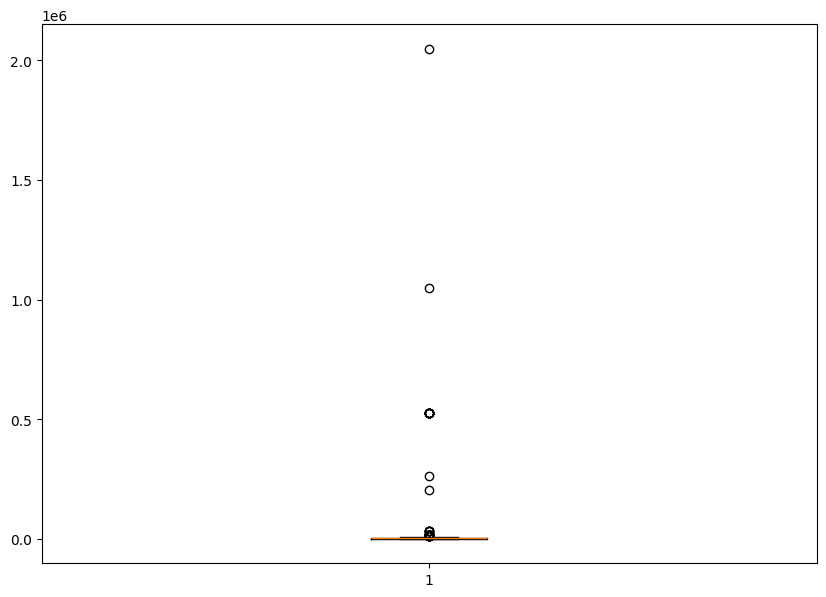

In [20]:
processor_plot= min['RAM_mb'].dropna()
fig = plt.figure(figsize = (10,7))
plt.boxplot(processor_plot)
plt.show()

In [23]:
#tech_spec_edit = min
tech_spec_edit.to_csv('tech_spec2.csv')

In [29]:
#Add rating proportion
df2_trimmed['pos_prop'] = (df2_trimmed['positive_ratings']/df2_trimmed['total_reviews'])
print(df2_trimmed['pos_prop'].head())

df2_trimmed['pos_prop'].describe()
#Plot:
sns.histplot((df2_trimmed['pos_prop']))

# Adding labels and title
plt.xlabel('pos_prop')
plt.ylabel('Density')
plt.title('overall_rating_proportions')

# Display the plot
plt.show()


NameError: name 'df2_trimmed' is not defined

In [ ]:
#Removing

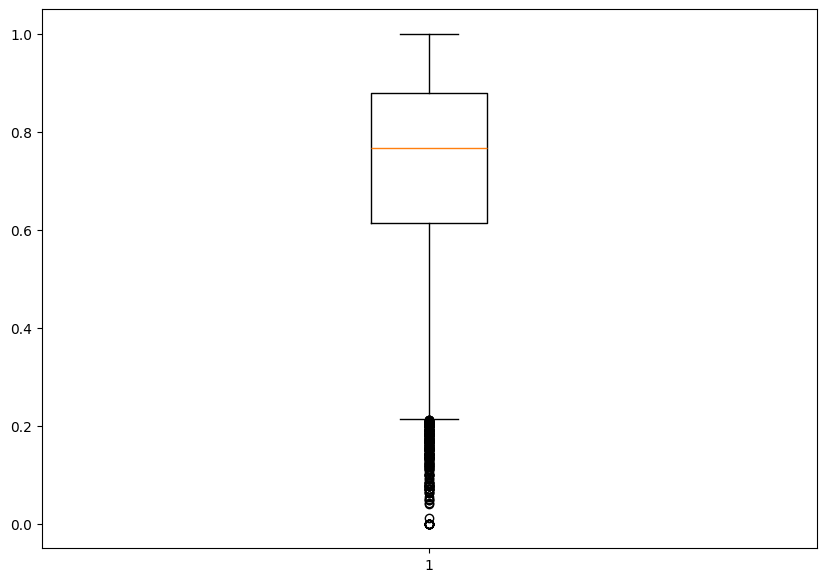

In [14]:
#Boxplot:
pos_prop= df2['pos_prop']
fig = plt.figure(figsize = (10,7))
plt.boxplot(pos_prop)
plt.show()